In [ ]:
# Import Required Libraries

import pandas as pd
import numpy as np

# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Date & Time
from datetime import datetime

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

# Display Settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Plot Style
plt.style.use("ggplot")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [ ]:
# Load Dataset

df = pd.read_csv("/content/queue_data.csv")

print("Dataset Loaded Successfully")

Dataset Loaded Successfully


In [ ]:
# Display First Five Records

df.head()

,arrival_time,start_time,finish_time,wait_time,queue_length
0,30-03-2023 0.10,30-03-2023 0.10,2023-03-30 00:22:44.800000000,12.68,28
1,30-03-2023 0.10,30-03-2023 0.16,2023-03-30 00:25:53.200000000,9.82,28
2,30-03-2023 0.10,30-03-2023 0.16,2023-03-30 00:25:48.400000000,9.74,28
3,30-03-2023 0.10,30-03-2023 0.14,2023-03-30 00:27:23.200000000,13.32,28
4,30-03-2023 0.10,30-03-2023 0.15,2023-03-30 00:31:21.400000000,16.29,28


In [ ]:
# Display Last Five Records

df.tail()

,arrival_time,start_time,finish_time,wait_time,queue_length
555,30-03-2023 22.00,30-03-2023 22.02,2023-03-30 22:16:59.800000000,14.83,12
556,30-03-2023 22.00,30-03-2023 22.10,2023-03-30 22:13:56.200000000,3.77,12
557,30-03-2023 22.00,30-03-2023 22.00,2023-03-30 22:05:35.799999999,5.43,12
558,30-03-2023 23.54,30-03-2023 23.54,2023-03-31 00:00:42.400000000,5.74,2
559,30-03-2023 23.54,30-03-2023 23.58,2023-03-31 00:17:23.200000000,18.42,2


In [ ]:
# Random Sample

df.sample(10, random_state=42)

,arrival_time,start_time,finish_time,wait_time,queue_length
453,30-03-2023 18.31,30-03-2023 18.32,2023-03-30 18:45:27.600000000,13.06,30
341,30-03-2023 13.55,30-03-2023 13.59,2023-03-30 14:13:24.400000000,13.64,25
177,30-03-2023 6.51,30-03-2023 6.58,2023-03-30 07:25:38.800000000,26.98,24
86,30-03-2023 3.02,30-03-2023 3.07,2023-03-30 03:17:52.199999999,10.62,45
332,30-03-2023 13.55,30-03-2023 14.05,2023-03-30 14:14:08.199999999,8.37,25
140,30-03-2023 5.34,30-03-2023 5.37,2023-03-30 05:46:46.800000000,9.48,50
272,30-03-2023 10.31,30-03-2023 10.33,2023-03-30 10:44:15.800000000,10.88,32
296,30-03-2023 12.33,30-03-2023 12.43,2023-03-30 12:51:53.799999999,8.78,40
101,30-03-2023 3.02,30-03-2023 3.10,2023-03-30 03:19:58.800000000,9.73,45
518,30-03-2023 21.09,30-03-2023 21.12,2023-03-30 21:14:43.200000000,1.87,44


In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 560
Columns : 5


In [ ]:
df.columns

Index(['arrival_time', 'start_time', 'finish_time', 'wait_time',
       'queue_length'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 560 entries, 0 to 559
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   arrival_time  560 non-null    object 
 1   start_time    560 non-null    object 
 2   finish_time   560 non-null    object 
 3   wait_time     560 non-null    float64
 4   queue_length  560 non-null    int64  
dtypes: float64(1), int64(1), object(3)
memory usage: 22.0+ KB


In [ ]:
df.describe()

,wait_time,queue_length
count,560.000000,560.000000
mean,10.107911,32.132143
std,5.032406,12.418048
min,-2.930000,2.000000
25%,6.527500,24.750000
50%,10.120000,30.000000
75%,13.322500,45.000000
max,26.980000,50.000000


In [ ]:
df.isnull().sum()

,0
arrival_time,0
start_time,0
finish_time,0
wait_time,0
queue_length,0


In [ ]:
missing = (df.isnull().sum()/len(df))*100

missing.sort_values(ascending=False)

,0
arrival_time,0.0
start_time,0.0
finish_time,0.0
wait_time,0.0
queue_length,0.0


In [ ]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 1


In [ ]:
df.drop_duplicates(inplace=True)

print("Duplicates Removed Successfully")

Duplicates Removed Successfully


In [ ]:
df.dtypes

,0
arrival_time,object
start_time,object
finish_time,object
wait_time,float64
queue_length,int64


In [ ]:
df["arrival_time"].head(10)

,arrival_time
0,30-03-2023 0.10
1,30-03-2023 0.10
2,30-03-2023 0.10
3,30-03-2023 0.10
4,30-03-2023 0.10
5,30-03-2023 0.10
6,30-03-2023 0.10
7,30-03-2023 0.10
8,30-03-2023 0.10
9,30-03-2023 0.10


In [ ]:
df["arrival_time"] = df["arrival_time"].str.replace(".", ":", regex=False)
df["start_time"] = df["start_time"].str.replace(".", ":", regex=False)
df["finish_time"] = df["finish_time"].str.replace(".", ":", regex=False)

In [ ]:
print(df["arrival_time"].head())
print("-" * 50)
print(df["start_time"].head())
print("-" * 50)
print(df["finish_time"].head())

0   2023-03-30 00:10:00
1   2023-03-30 00:10:00
2   2023-03-30 00:10:00
3   2023-03-30 00:10:00
4   2023-03-30 00:10:00
Name: arrival_time, dtype: datetime64[ns]
--------------------------------------------------
0   2023-03-30 00:10:00
1   2023-03-30 00:16:00
2   2023-03-30 00:16:00
3   2023-03-30 00:14:00
4   2023-03-30 00:15:00
Name: start_time, dtype: datetime64[ns]
--------------------------------------------------
0    2023-03-30 00:22:44:800000000
1    2023-03-30 00:25:53:200000000
2    2023-03-30 00:25:48:400000000
3    2023-03-30 00:27:23:200000000
4    2023-03-30 00:31:21:400000000
Name: finish_time, dtype: object


In [ ]:
# Replace the last ":" before nanoseconds with "."

df["finish_time"] = (
    df["finish_time"]
    .str.replace(r'(\d{2}:\d{2}:\d{2}):(\d+)$', r'\1.\2', regex=True)
)

# Convert to datetime
df["finish_time"] = pd.to_datetime(df["finish_time"])

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 559 entries, 0 to 559
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   arrival_time  559 non-null    datetime64[ns]
 1   start_time    559 non-null    datetime64[ns]
 2   finish_time   559 non-null    datetime64[ns]
 3   wait_time     559 non-null    float64       
 4   queue_length  559 non-null    int64         
dtypes: datetime64[ns](3), float64(1), int64(1)
memory usage: 26.2 KB


In [ ]:
df["arrival_hour"] = df["arrival_time"].dt.hour

In [ ]:
df["arrival_minute"] = df["arrival_time"].dt.minute

In [ ]:
df["arrival_day"] = df["arrival_time"].dt.day

In [ ]:
df["arrival_month"] = df["arrival_time"].dt.month

In [ ]:
df["day_name"] = df["arrival_time"].dt.day_name()

In [ ]:
df["is_weekend"] = df["day_name"].isin(
    ["Saturday","Sunday"]
).astype(int)

In [ ]:
df["service_time"] = (
    df["finish_time"] -
    df["start_time"]
).dt.total_seconds()/60

In [ ]:
df["total_time"] = (
    df["finish_time"] -
    df["arrival_time"]
).dt.total_seconds()/60

In [ ]:
df.head()

,arrival_time,start_time,finish_time,wait_time,queue_length,arrival_hour,arrival_minute,arrival_day,arrival_month,day_name,is_weekend,service_time,total_time
0,2023-03-30 00:10:00,2023-03-30 00:10:00,2023-03-30 00:22:44.800,12.68,28,0,10,30,3,Thursday,0,12.746667,12.746667
1,2023-03-30 00:10:00,2023-03-30 00:16:00,2023-03-30 00:25:53.200,9.82,28,0,10,30,3,Thursday,0,9.886667,15.886667
2,2023-03-30 00:10:00,2023-03-30 00:16:00,2023-03-30 00:25:48.400,9.74,28,0,10,30,3,Thursday,0,9.806667,15.806667
3,2023-03-30 00:10:00,2023-03-30 00:14:00,2023-03-30 00:27:23.200,13.32,28,0,10,30,3,Thursday,0,13.386667,17.386667
4,2023-03-30 00:10:00,2023-03-30 00:15:00,2023-03-30 00:31:21.400,16.29,28,0,10,30,3,Thursday,0,16.356667,21.356667


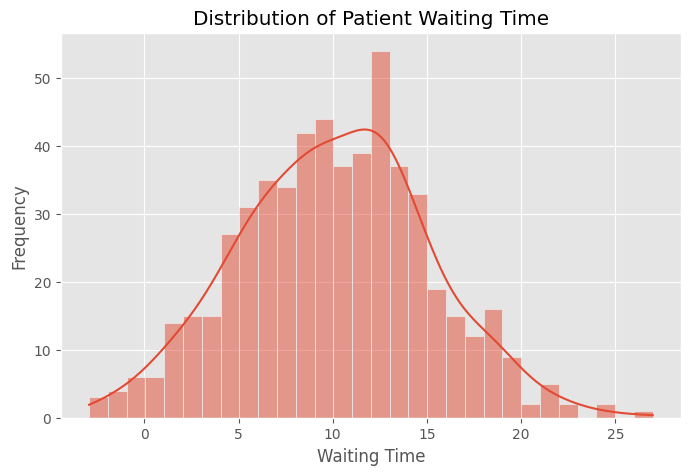

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["wait_time"], bins=30, kde=True)

plt.title("Distribution of Patient Waiting Time")
plt.xlabel("Waiting Time")
plt.ylabel("Frequency")

plt.show()

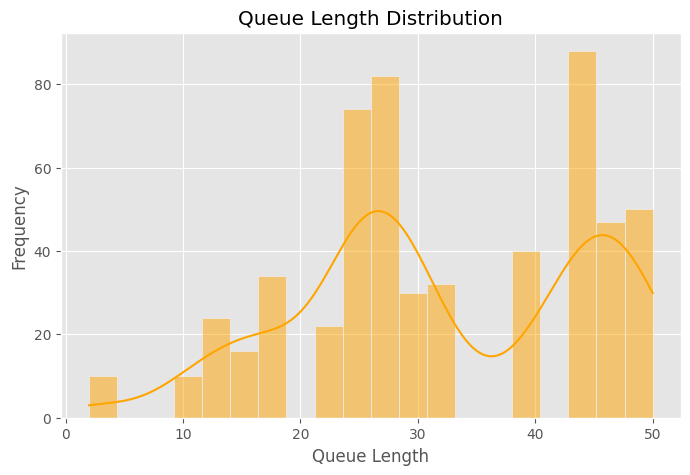

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["queue_length"], bins=20, color="orange", kde=True)

plt.title("Queue Length Distribution")
plt.xlabel("Queue Length")
plt.ylabel("Frequency")

plt.show()

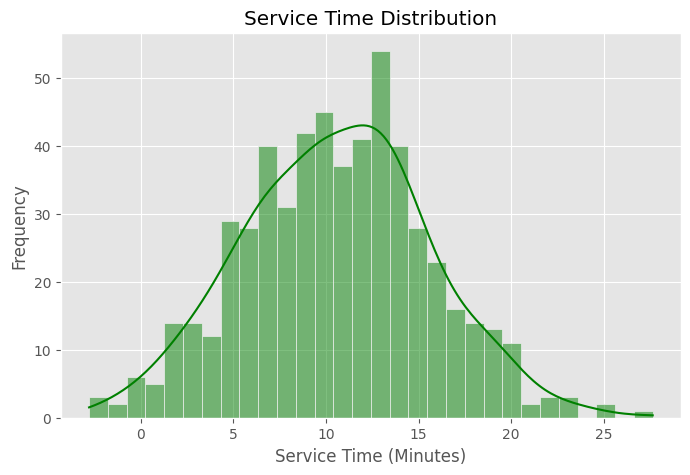

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["service_time"], bins=30, color="green", kde=True)

plt.title("Service Time Distribution")
plt.xlabel("Service Time (Minutes)")
plt.ylabel("Frequency")

plt.show()

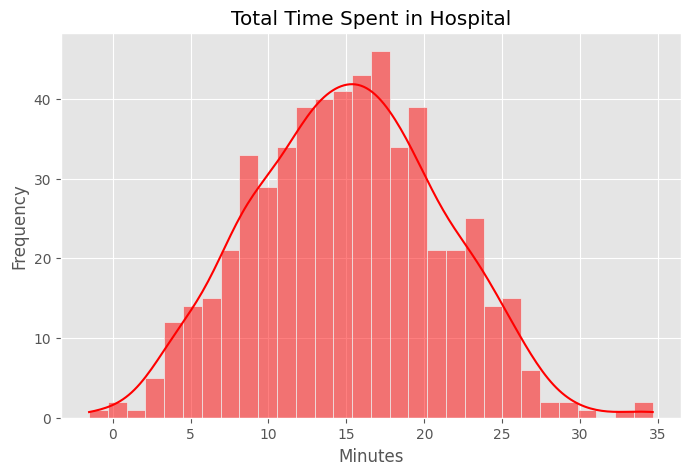

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["total_time"], bins=30, color="red", kde=True)

plt.title("Total Time Spent in Hospital")
plt.xlabel("Minutes")
plt.ylabel("Frequency")

plt.show()

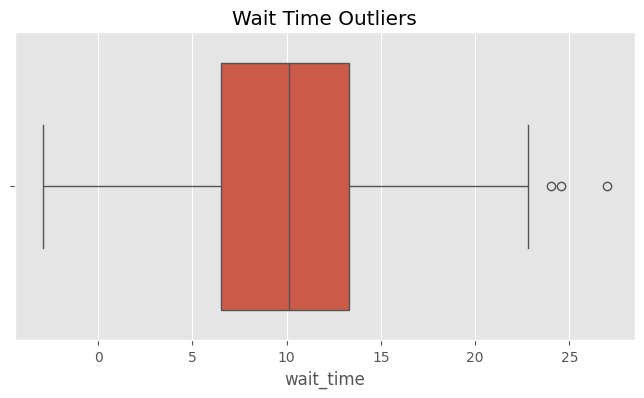

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["wait_time"])

plt.title("Wait Time Outliers")

plt.show()

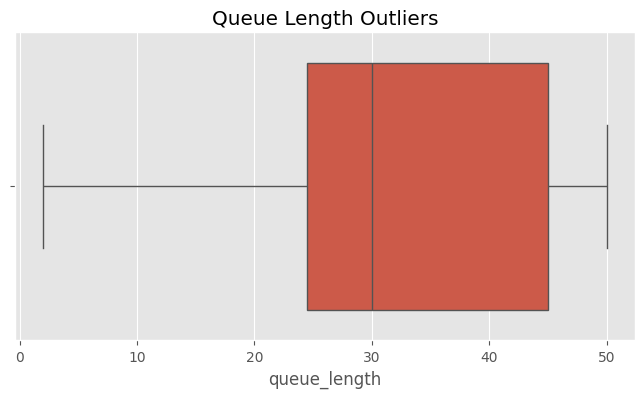

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["queue_length"])

plt.title("Queue Length Outliers")

plt.show()

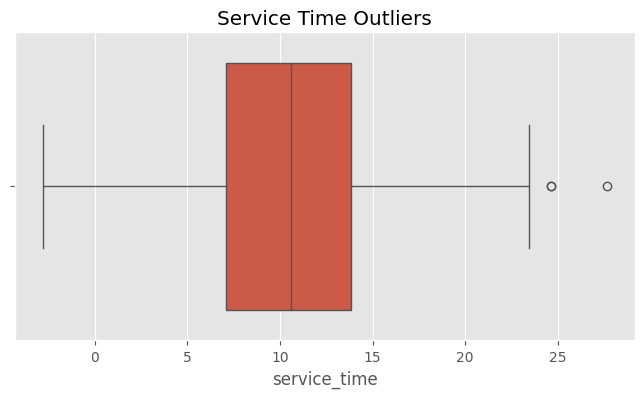

In [ ]:
plt.figure(figsize=(8,4))

sns.boxplot(x=df["service_time"])

plt.title("Service Time Outliers")

plt.show()

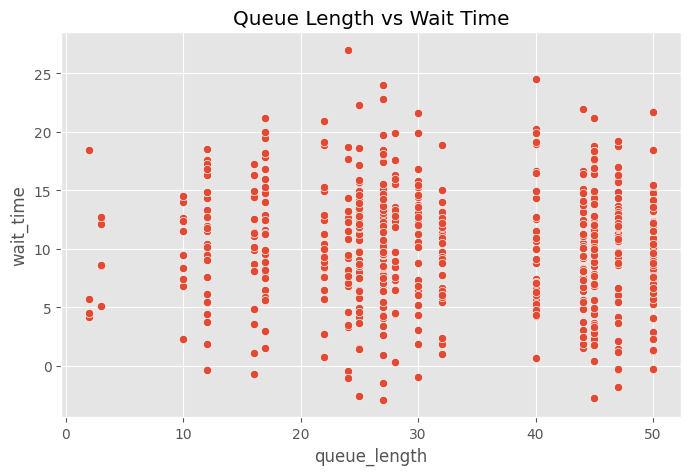

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="queue_length",
    y="wait_time",
    data=df
)

plt.title("Queue Length vs Wait Time")

plt.show()

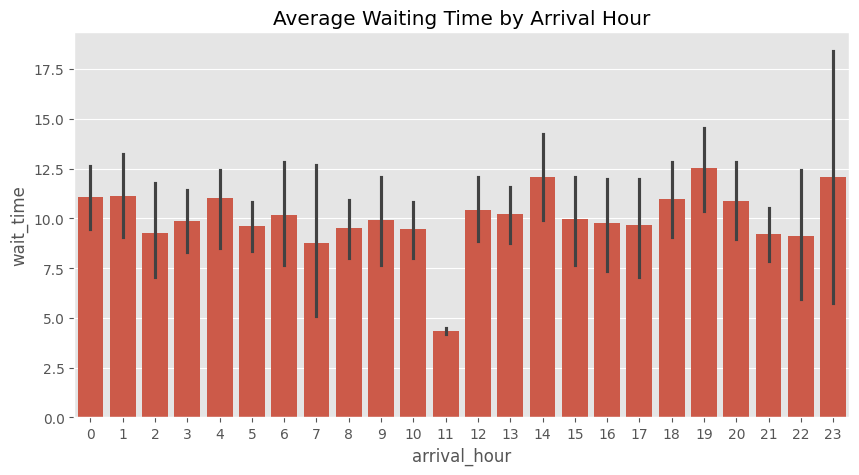

In [ ]:
plt.figure(figsize=(10,5))

sns.barplot(
    x="arrival_hour",
    y="wait_time",
    data=df
)

plt.title("Average Waiting Time by Arrival Hour")

plt.show()

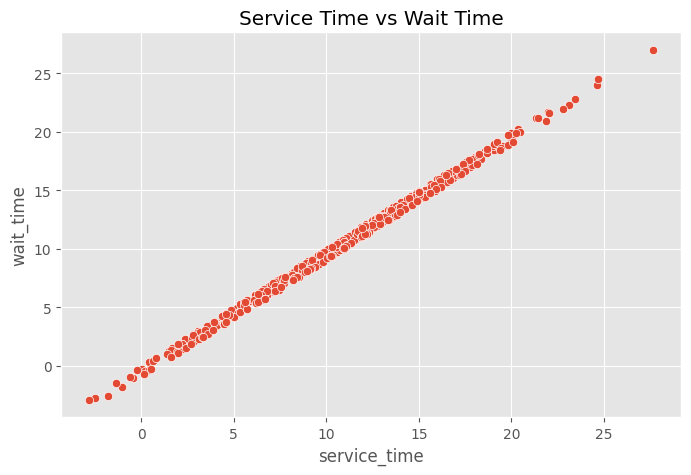

In [ ]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="service_time",
    y="wait_time",
    data=df
)

plt.title("Service Time vs Wait Time")

plt.show()

In [ ]:
peak_hours = df.groupby("arrival_hour")["wait_time"].mean().reset_index()

peak_hours

,arrival_hour,wait_time
0,0,11.077857
1,1,11.108148
2,2,9.277059
3,3,9.873778
4,4,11.010000
5,5,9.611600
6,6,10.192083
7,7,8.780000
8,8,9.494255
9,9,9.938000


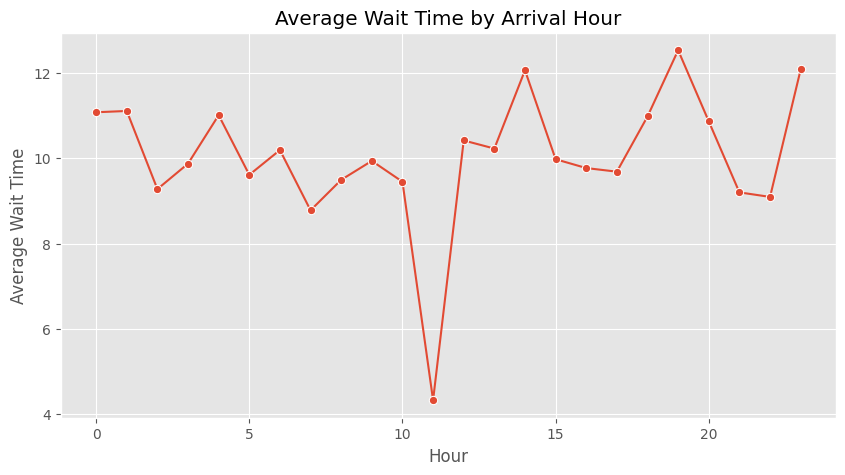

In [ ]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x="arrival_hour",
    y="wait_time",
    data=peak_hours,
    marker="o"
)

plt.title("Average Wait Time by Arrival Hour")

plt.xlabel("Hour")

plt.ylabel("Average Wait Time")

plt.show()

In [ ]:
peak_hours.sort_values(
    by="wait_time",
    ascending=False
).head(10)

,arrival_hour,wait_time
19,19,12.531667
23,23,12.080000
14,14,12.061765
1,1,11.108148
0,0,11.077857
4,4,11.010000
18,18,10.979333
20,20,10.864091
12,12,10.417250
13,13,10.227200


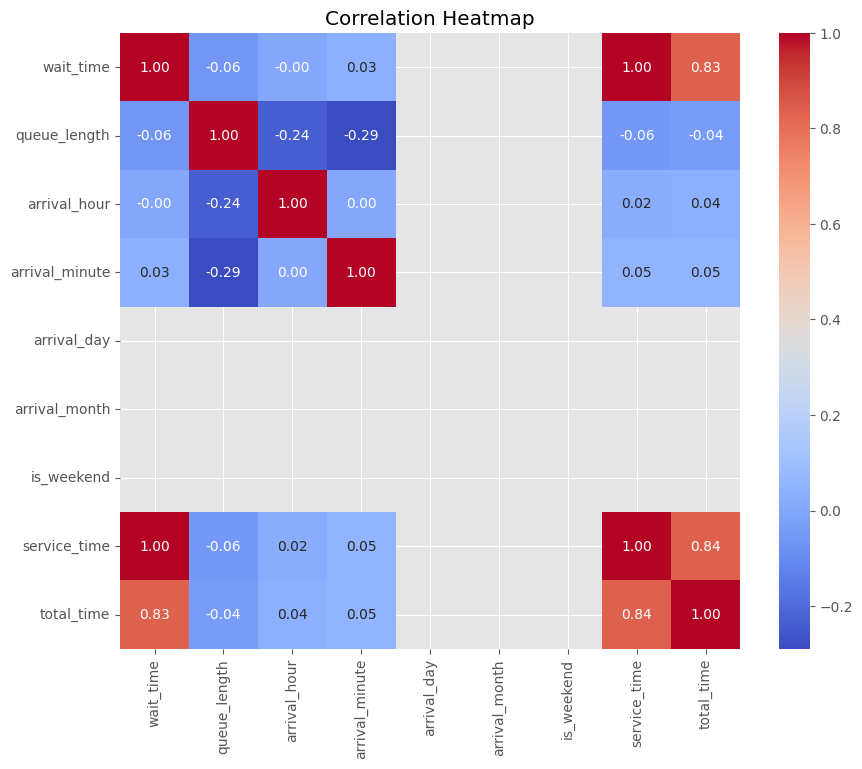

In [ ]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(10,8))

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
X = df.drop(
    columns=[
        "wait_time",
        "arrival_time",
        "start_time",
        "finish_time",
        "day_name"
    ]
)

y = df["wait_time"]

In [ ]:
X.head()

,queue_length,arrival_hour,arrival_minute,arrival_day,arrival_month,is_weekend,service_time,total_time
0,28,0,10,30,3,0,12.746667,12.746667
1,28,0,10,30,3,0,9.886667,15.886667
2,28,0,10,30,3,0,9.806667,15.806667
3,28,0,10,30,3,0,13.386667,17.386667
4,28,0,10,30,3,0,16.356667,21.356667


In [ ]:
y.head()

,wait_time
0,12.68
1,9.82
2,9.74
3,13.32
4,16.29


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [ ]:
print("Training Features :", X_train.shape)

print("Testing Features :", X_test.shape)

print("Training Target :", y_train.shape)

print("Testing Target :", y_test.shape)

Training Features : (447, 8)
Testing Features : (112, 8)
Training Target : (447,)
Testing Target : (112,)


In [ ]:
df.to_csv(
    "cleaned_queue_data.csv",
    index=False
)

print("Cleaned Dataset Saved Successfully")

Cleaned Dataset Saved Successfully


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("Machine Learning Libraries Imported Successfully")

Machine Learning Libraries Imported Successfully


In [ ]:
# Create Model

lr_model = LinearRegression()

# Train Model

lr_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully")

Linear Regression Model Trained Successfully


In [ ]:
lr_prediction = lr_model.predict(X_test)

lr_prediction[:10]

array([13.36951954,  9.93659833, 11.47931669,  6.4907387 ,  5.43097614,
       12.30240981, 13.04673473, 18.40195912,  8.5159484 ,  8.48438838])

In [ ]:
lr_mae = mean_absolute_error(y_test, lr_prediction)

lr_mse = mean_squared_error(y_test, lr_prediction)

lr_rmse = np.sqrt(lr_mse)

lr_r2 = r2_score(y_test, lr_prediction)

print("Linear Regression Performance")

print("MAE :", lr_mae)

print("MSE :", lr_mse)

print("RMSE :", lr_rmse)

print("R2 Score :", lr_r2)

Linear Regression Performance
MAE : 0.20096867852681097
MSE : 0.05674848370398555
RMSE : 0.23821940245073564
R2 Score : 0.9976365921646738


In [ ]:
rf_model = RandomForestRegressor(

    n_estimators=200,

    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest Model Trained Successfully")

Random Forest Model Trained Successfully


In [ ]:
rf_prediction = rf_model.predict(X_test)

rf_prediction[:10]

array([13.2785 ,  9.9798 , 11.5391 ,  6.5093 ,  5.09945, 12.4066 ,
       13.1748 , 18.36775,  8.5043 ,  8.6322 ])

In [ ]:
rf_mae = mean_absolute_error(y_test, rf_prediction)

rf_mse = mean_squared_error(y_test, rf_prediction)

rf_rmse = np.sqrt(rf_mse)

rf_r2 = r2_score(y_test, rf_prediction)

print("Random Forest Performance")

print("MAE :", rf_mae)

print("MSE :", rf_mse)

print("RMSE :", rf_rmse)

print("R2 Score :", rf_r2)

Random Forest Performance
MAE : 0.2716879464285712
MSE : 0.17282486868303368
RMSE : 0.41572210511714874
R2 Score : 0.9928023513206923


In [ ]:
xgb_model = XGBRegressor(

    n_estimators=200,

    learning_rate=0.1,

    random_state=42
)

xgb_model.fit(X_train, y_train)

print("XGBoost Model Trained Successfully")

XGBoost Model Trained Successfully


In [ ]:
xgb_prediction = xgb_model.predict(X_test)

xgb_prediction[:10]

array([13.407961 , 10.226703 , 11.409346 ,  6.3568487,  5.1260386,
       12.210668 , 12.999665 , 18.497723 ,  8.451412 ,  8.737428 ],
      dtype=float32)

In [ ]:
xgb_mae = mean_absolute_error(y_test, xgb_prediction)

xgb_mse = mean_squared_error(y_test, xgb_prediction)

xgb_rmse = np.sqrt(xgb_mse)

xgb_r2 = r2_score(y_test, xgb_prediction)

print("XGBoost Performance")

print("MAE :", xgb_mae)

print("MSE :", xgb_mse)

print("RMSE :", xgb_rmse)

print("R2 Score :", xgb_r2)

XGBoost Performance
MAE : 0.19786590327109607
MSE : 0.11263396828194892
RMSE : 0.33560984532928845
R2 Score : 0.9953091257107413


In [ ]:
comparison = pd.DataFrame({

    "Model":[

        "Linear Regression",

        "Random Forest",

        "XGBoost"

    ],

    "MAE":[

        lr_mae,

        rf_mae,

        xgb_mae

    ],

    "RMSE":[

        lr_rmse,

        rf_rmse,

        xgb_rmse

    ],

    "R2 Score":[

        lr_r2,

        rf_r2,

        xgb_r2

    ]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.200969,0.238219,0.997637
1,Random Forest,0.271688,0.415722,0.992802
2,XGBoost,0.197866,0.335610,0.995309


In [ ]:
comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
0,Linear Regression,0.200969,0.238219,0.997637
2,XGBoost,0.197866,0.335610,0.995309
1,Random Forest,0.271688,0.415722,0.992802


In [ ]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":rf_model.feature_importances_

})

importance.sort_values(

    by="Importance",

    ascending=False,

    inplace=True
)

importance

,Feature,Importance
6,service_time,0.997382
7,total_time,0.000875
1,arrival_hour,0.000729
2,arrival_minute,0.000531
0,queue_length,0.000483
3,arrival_day,0.000000
5,is_weekend,0.000000
4,arrival_month,0.000000


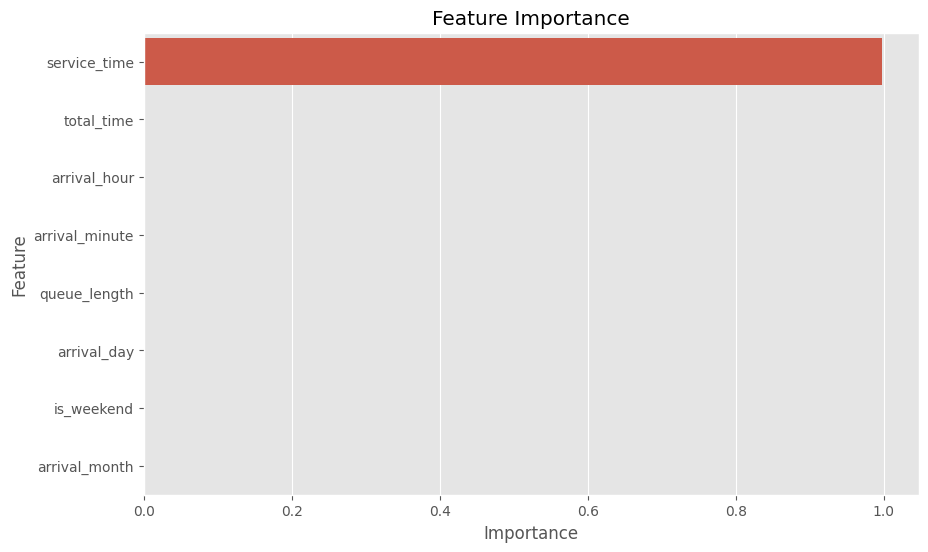

In [ ]:
plt.figure(figsize=(10,6))

sns.barplot(

    x="Importance",

    y="Feature",

    data=importance

)

plt.title("Feature Importance")

plt.show()

In [ ]:
results = pd.DataFrame({

    "Actual":y_test,

    "Predicted":rf_prediction

})

results.head(20)

,Actual,Predicted
158,13.53,13.27850
451,10.13,9.97980
55,11.59,11.53910
247,6.85,6.50930
70,5.53,5.09945
376,12.08,12.40660
382,12.83,13.17480
81,18.38,18.36775
517,8.26,8.50430
144,8.63,8.63220


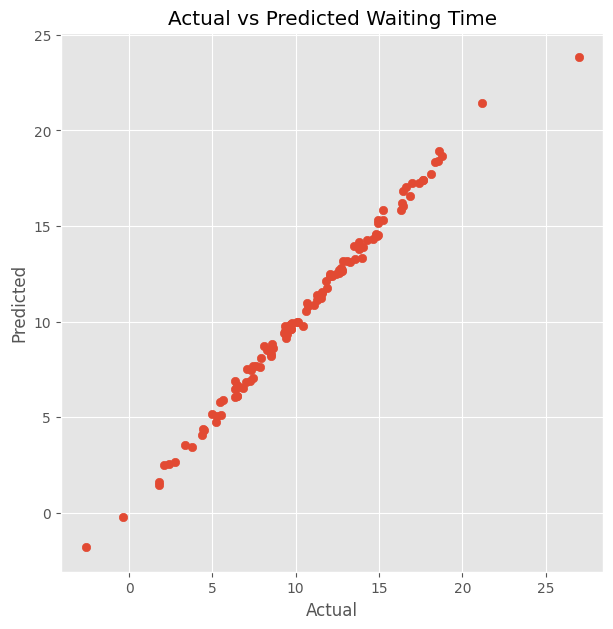

In [ ]:
plt.figure(figsize=(7,7))

plt.scatter(

    y_test,

    rf_prediction

)

plt.xlabel("Actual")

plt.ylabel("Predicted")

plt.title("Actual vs Predicted Waiting Time")

plt.show()

In [ ]:
joblib.dump(

    rf_model,

    "patient_wait_time_model.pkl"

)

print("Model Saved Successfully")

Model Saved Successfully


In [ ]:
loaded_model = joblib.load(

    "patient_wait_time_model.pkl"

)

print("Model Loaded Successfully")

Model Loaded Successfully


In [ ]:
new_patient = pd.DataFrame({

    "queue_length":[8],

    "arrival_hour":[10],

    "arrival_minute":[30],

    "arrival_day":[30],

    "arrival_month":[3],

    "is_weekend":[0],

    "service_time":[15],

    "total_time":[30]

})

prediction = loaded_model.predict(new_patient)

print("Predicted Waiting Time (Minutes):", prediction[0])

Predicted Waiting Time (Minutes): 14.606049999999998


In [ ]:
print("="*60)

print("MODEL PERFORMANCE SUMMARY")

print("="*60)

print(comparison)

print("="*60)

MODEL PERFORMANCE SUMMARY
               Model       MAE      RMSE  R2 Score
0  Linear Regression  0.200969  0.238219  0.997637
1      Random Forest  0.271688  0.415722  0.992802
2            XGBoost  0.197866  0.335610  0.995309
